**Chapter 18 – Reinforcement Learning**

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20 and TensorFlow ≥2.0.

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# To get smooth animations
import matplotlib.animation as animation
mpl.rc('animation', html='jshtml')

# Introduction to OpenAI gym

In this notebook we will be using [OpenAI gym](https://gym.openai.com/), a great toolkit for developing and comparing Reinforcement Learning algorithms. It provides many environments for your learning *agents* to interact with. Let's start by importing `gym`:

In [2]:
import gym

Let's list all the available environments:

In [3]:
gym.envs.registry.all()

dict_values([EnvSpec(Copy-v0), EnvSpec(RepeatCopy-v0), EnvSpec(ReversedAddition-v0), EnvSpec(ReversedAddition3-v0), EnvSpec(DuplicatedInput-v0), EnvSpec(Reverse-v0), EnvSpec(CartPole-v0), EnvSpec(CartPole-v1), EnvSpec(MountainCar-v0), EnvSpec(MountainCarContinuous-v0), EnvSpec(Pendulum-v0), EnvSpec(Acrobot-v1), EnvSpec(LunarLander-v2), EnvSpec(LunarLanderContinuous-v2), EnvSpec(BipedalWalker-v3), EnvSpec(BipedalWalkerHardcore-v3), EnvSpec(CarRacing-v0), EnvSpec(Blackjack-v0), EnvSpec(KellyCoinflip-v0), EnvSpec(KellyCoinflipGeneralized-v0), EnvSpec(FrozenLake-v0), EnvSpec(FrozenLake8x8-v0), EnvSpec(CliffWalking-v0), EnvSpec(NChain-v0), EnvSpec(Roulette-v0), EnvSpec(Taxi-v3), EnvSpec(GuessingGame-v0), EnvSpec(HotterColder-v0), EnvSpec(Reacher-v2), EnvSpec(Pusher-v2), EnvSpec(Thrower-v2), EnvSpec(Striker-v2), EnvSpec(InvertedPendulum-v2), EnvSpec(InvertedDoublePendulum-v2), EnvSpec(HalfCheetah-v2), EnvSpec(HalfCheetah-v3), EnvSpec(Hopper-v2), EnvSpec(Hopper-v3), EnvSpec(Swimmer-v2), EnvSp

The Cart-Pole is a very simple environment composed of a cart that can move left or right, and pole placed vertically on top of it. The agent must move the cart left or right to keep the pole upright.

![cart-pole](images/openai-gym.png "Cart-Pole")

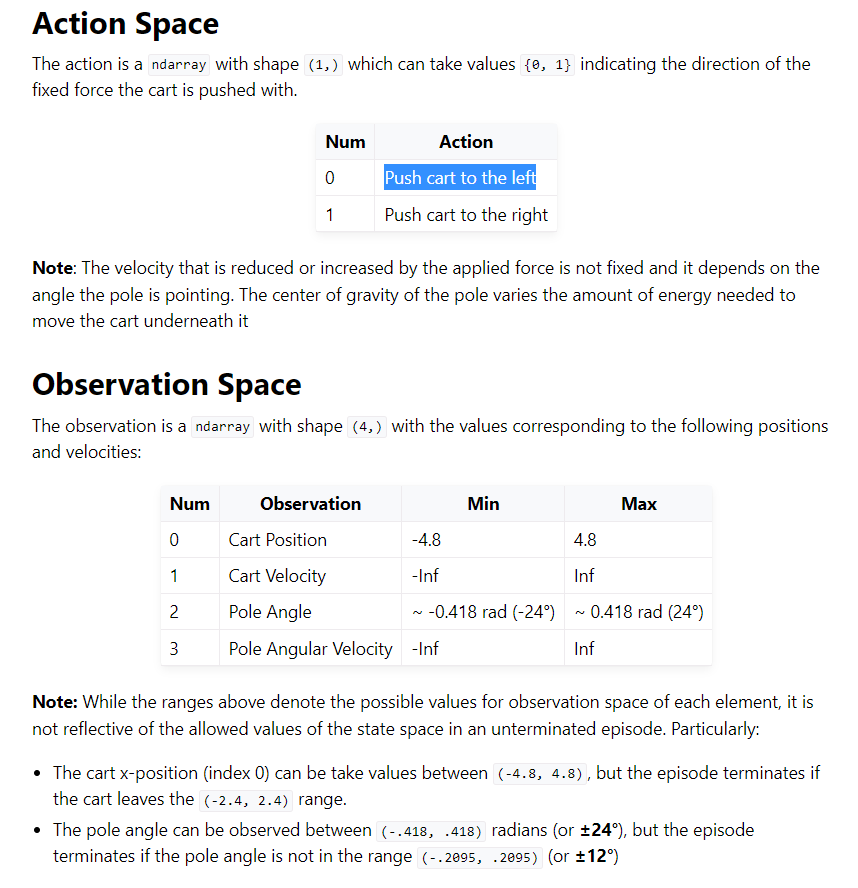

https://www.gymlibrary.dev/environments/classic_control/cart_pole/

In [4]:
env = gym.make('CartPole-v1')

Let's initialize the environment by calling is `reset()` method. This returns an observation:

In [5]:
env.seed(42)
obs = env.reset()

In [6]:
env.observation_space

Box(4,)

Observations vary depending on the environment. In this case it is a 1D NumPy array composed of 4 floats: they represent the cart's horizontal position, its velocity, the angle of the pole (0 = vertical), and the angular velocity.

In [8]:
obs

array([-0.01258566, -0.00156614,  0.04207708, -0.00180545])

Now let's view the environment:

![cart-pole](images/cart-pole-image1.png "Cart-Pole")

Let's see how to interact with an environment. Your agent will need to select an action from an "action space" (the set of possible actions). Let's see what this environment's action space looks like:

In [9]:
env.action_space

Discrete(2)

Yep, just two possible actions: accelerate towards the left or towards the right. Since the pole is leaning toward the right (`obs[2] > 0`), let's accelerate the cart toward the right:

In [56]:
obs

array([-0.01258566, -0.00156614,  0.04207708, -0.00180545])

In [10]:
action = 0 # accelerate right

# The step() method executes the given action and returns four values
obs, reward, done, info = env.step(action)

# obs = This is the new observation

# reward = In this environment, you get a reward of 1.0 at every step, no matter what you do,
# so the goal is to keep the episode running as long as possible

# done = This value will be True when the episode is over. This will happen when the pole
# tilts too much, or goes off the screen, or after 200 steps (in this last case, you have
# won). After that, the environment must be reset before it can be used again.

# info = This environment-specific dictionary can provide some extra information that
# you may find useful for debugging or for training.

obs, done, reward, info

(array([-0.01261699, -0.19726549,  0.04204097,  0.30385076]), False, 1.0, {})

In [11]:
import random


In [15]:
for i in range(10):
    print()

0
1
0
0
1
1
1
0
1
1


In [16]:
def play_game_random(env):
    obs = env.reset()
    count = 0
    print("Started. Obs: ", obs)
    while True:
        action = random.randrange(0, 2)
        obs, reward, done, info = env.step(action)
        if done:
            print(f"Done! Actions: {count}")
            break
        count += 1
    return count

In [18]:
for i in range(10):
    count = play_game_random(env)
    print(i, count)

Started. Obs:  [-0.03056663  0.02063487  0.01650017  0.04869769]
Done! Actions: 43
0 43
Started. Obs:  [-0.0313163   0.03775876 -0.01135978 -0.01095196]
Done! Actions: 14
1 14
Started. Obs:  [-0.01303166 -0.04270197 -0.04540492  0.04584364]
Done! Actions: 64
2 64
Started. Obs:  [-0.03880929  0.04082397 -0.03952141 -0.04224303]
Done! Actions: 8
3 8
Started. Obs:  [ 0.04905493 -0.0212186  -0.03840544 -0.01126453]
Done! Actions: 19
4 19
Started. Obs:  [-0.02634648  0.03966961 -0.02548931  0.03561763]
Done! Actions: 16
5 16
Started. Obs:  [ 0.03774805  0.02149584 -0.04331595 -0.00408086]
Done! Actions: 16
6 16
Started. Obs:  [-0.0351136  -0.02891661  0.0417589   0.01221591]
Done! Actions: 16
7 16
Started. Obs:  [ 0.03340553 -0.04100693 -0.0397862  -0.03355728]
Done! Actions: 18
8 18
Started. Obs:  [-0.00463403 -0.03226874  0.02540731 -0.04842035]
Done! Actions: 36
9 36


In [58]:
def play_game_sk(seed=None):
    env._max_episode_steps = 2000
    if seed:
        env.seed(seed)
    obs = env.reset()
    print("Started. Obs: ", obs)
    count = 0
    while True:
        if obs[2] > 0:
            action = 1
        else:
            action = 0
        obs, reward, done, info = env.step(action)
        count += 1
        print(f"{count} - Obs: {obs}, Reward: {reward}, Done: {done}, Info: {info}")
        if done:
            print(f"Done! Actions: {count}")
            break
    return count

In [ ]:
rewards = [play_game_sk() for _ in range(100)]

In [ ]:
max(rewards), min(rewards), sum(rewards)/len(rewards)

Notice that the cart is now moving toward the right (`obs[1] > 0`). The pole is still tilted toward the right (`obs[2] > 0`), but its angular velocity is now negative (`obs[3] < 0`), so it will likely be tilted toward the left after the next step.

In [158]:
def play_game_sk_1(seed=None):
    env._max_episode_steps = 5000
    if seed:
        env.seed(seed)
    obs = env.reset()
    print("Started. Obs: ", obs)
    count = 0
    while True:
        if obs[2]+obs[3] > 0:
            action = 1
        else:
            action = 0
        obs, reward, done, info = env.step(action)
        count += 1
        print(f"{count} - Obs: {obs}, Reward: {reward}, Done: {done}, Info: {info}")
        if done:
            print(f"Done! Actions: {count}")
            break
    return count


In [ ]:
def test_policy(pl):
    rewards = [pl() for _ in range(100)]
    print(max(rewards), min(rewards), sum(rewards)/len(rewards))
test_policy(play_game_sk_1)

In [ ]:
def play_game_sk_2(seed=None, p1, p2, p3):
    env._max_episode_steps = 5000
    if seed:
        env.seed(seed)
    obs = env.reset()
    print("Started. Obs: ", obs)
    count = 0
    while True:
        if p1*obs[2]+ p2*obs[3] + p3 > 0:
            action = 1
        else:
            action = 0
        obs, reward, done, info = env.step(action)
        count += 1
        print(f"{count} - Obs: {obs}, Reward: {reward}, Done: {done}, Info: {info}")
        if done:
            print(f"Done! Actions: {count}")
            break
    return count


In [ ]:
def play_game_sk_3(seed=None):
    env._max_episode_steps = 5000
    if seed:
        env.seed(seed)
    obs = env.reset()
    print("Started. Obs: ", obs)
    count = 0
    while True:
        action = TODO: ...
        obs, reward, done, info = env.step(action)
        count += 1
        print(f"{count} - Obs: {obs}, Reward: {reward}, Done: {done}, Info: {info}")
        if done:
            print(f"Done! Actions: {count}")
            break
    return count

![cart-pole](images/cart-pole-image2.png "Cart-Pole")

Looks like it's doing what we're telling it to do!

In [45]:
env.seed(42)
print(env.reset())

[-0.01258566 -0.00156614  0.04207708 -0.00180545]


In [46]:
env.seed(42)
print(env.reset())

[-0.01258566 -0.00156614  0.04207708 -0.00180545]


In [48]:
env.seed(42)
print(env.reset())
print(env.reset())
print(env.reset())


[-0.01258566 -0.00156614  0.04207708 -0.00180545]
[ 0.00560942  0.01842265 -0.03590751 -0.0120678 ]
[-0.03056663  0.02063487  0.01650017  0.04869769]


In [49]:
env.seed(42)
print(env.reset())
print(env.reset())
print(env.reset())


[-0.01258566 -0.00156614  0.04207708 -0.00180545]
[ 0.00560942  0.01842265 -0.03590751 -0.0120678 ]
[-0.03056663  0.02063487  0.01650017  0.04869769]


The environment also tells the agent how much reward it got during the last step:

In [ ]:
reward

When the game is over, the environment returns `done=True`:

In [ ]:
done

Finally, `info` is an environment-specific dictionary that can provide some extra information that you may find useful for debugging or for training. For example, in some games it may indicate how many lives the agent has.

In [ ]:
info

The sequence of steps between the moment the environment is reset until it is done is called an "episode". At the end of an episode (i.e., when `step()` returns `done=True`), you should reset the environment before you continue to use it.

In [ ]:
if done:
    obs = env.reset()

Now how can we make the poll remain upright? We will need to define a _policy_ for that. This is the strategy that the agent will use to select an action at each step. It can use all the past actions and observations to decide what to do.

**Go Back to the Slides**

# A simple hard-coded policy

Let's hard code a simple strategy: if the pole is tilting to the left, then push the cart to the left, and _vice versa_. Let's see if that works:

In [149]:
env.seed(42)
env._max_episode_steps = 2000

In [150]:
def basic_policy(obs):
    angle = obs[2]
    if angle < 0:
        return 0
    else:
        return 1

totals = []
for episode in range(500):
    episode_rewards = 0
    obs = env.reset()
    for step in range(2000):
        action = basic_policy(obs)
        obs, reward, done, info = env.step(action)
        episode_rewards += reward
        if done:
            break
    totals.append(episode_rewards)

In [151]:
totals.sort()
sum(totals)/len(totals)


41.718

Let’s look at the result:

In [152]:
np.mean(totals), np.std(totals), np.min(totals), np.max(totals)

(41.718, 8.858356280936096, 24.0, 68.0)

Well, as expected, this strategy is a bit too basic: the best it did was to keep the poll up for only 68 steps. This environment is considered solved when the agent keeps the poll up for 200 steps.

Let's visualize one episode and see the animation:

<video controls src="videos/cart-pole-video1.mp4" />

Clearly the system is unstable and after just a few wobbles, the pole ends up too tilted: game over. We will need to be smarter than that!

# Neural Network Policies

Let's create a neural network that will take observations as inputs, and output the action to take for each observation. To choose an action, the network will estimate a probability for each action, then we will select an action randomly according to the estimated probabilities. In the case of the Cart-Pole environment, there are just two possible actions (left or right), so we only need one output neuron: it will output the probability `p` of the action 0 (left), and of course the probability of action 1 (right) will be `1 - p`.

In [101]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

n_inputs = 4 # == env.observation_space.shape[0]

model = keras.models.Sequential([
    keras.layers.Dense(5, activation="elu", input_shape=[n_inputs]),
    keras.layers.Dense(1, activation="sigmoid"),
])

In this particular environment, the past actions and observations can safely be ignored, since each observation contains the environment's full state. If there were some hidden state then you may need to consider past actions and observations in order to try to infer the hidden state of the environment. For example, if the environment only revealed the position of the cart but not its velocity, you would have to consider not only the current observation but also the previous observation in order to estimate the current velocity. Another example is if the observations are noisy: you may want to use the past few observations to estimate the most likely current state. Our problem is thus as simple as can be: the current observation is noise-free and contains the environment's full state.

You may wonder why we plan to pick a random action based on the probability given by the policy network, rather than just picking the action with the highest probability. This approach lets the agent find the right balance between _exploring_ new actions and _exploiting_ the actions that are known to work well. Here's an analogy: suppose you go to a restaurant for the first time, and all the dishes look equally appealing so you randomly pick one. If it turns out to be good, you can increase the probability to order it next time, but you shouldn't increase that probability to 100%, or else you will never try out the other dishes, some of which may be even better than the one you tried.

Let's write a small function that will run the model to play one episode, and return the frames so we can display an animation:

In [104]:
def render_policy_net(model, n_max_steps=200, seed=42):
    frames = []
    env = gym.make("CartPole-v1")
    env._max_episode_steps = n_max_steps
    env.seed(seed)
    np.random.seed(seed)
    obs = env.reset()
    for step in range(n_max_steps):
        frames.append(1) #env.render(mode="rgb_array"))
        left_proba = model.predict(obs.reshape(1, -1))
        action = int(np.random.rand() > left_proba) #if left_proba = 0.7, action = 1 30%, action = 0 70%
        obs, reward, done, info = env.step(action)
        if done:
            break
    env.close()
    return frames

Now let's look at how well this randomly initialized policy network performs:

<video controls src="videos/cart-pole-video2.mp4" />

Yeah... pretty bad. The neural network will have to learn to do better. First let's see if it is capable of learning the basic policy we used earlier: go left if the pole is tilting left, and go right if it is tilting right.

We can make the same net play in 50 different environments in parallel (this will give us a diverse training batch at each step), and train for 5000 iterations. We also reset environments when they are done. We train the model using a custom training loop so we can easily use the predictions at each training step to advance the environments.

**Please note:** We have set the number of iterations to 50 in order to reduce the execution time during lectures. Please feel free to uncomment the original code and run it in the lab.

In [ ]:

# 0.8, out of 10 times it should approx 8 times head, 2 times tail

def biased_coin(prob_head):
    if np.random.rand() <= prob_head:
        print("Head")
    else:
        print("Tail")


In [46]:
# Engineering the serendipity
import numpy as np
p_left = 0.4
p_right = 1-p_left
all_actions = np.array([p_left, p_right])
all_actions

array([0.4, 0.6])

In [45]:
temp = 0.06
exp= np.exp(all_actions/temp)
normalized = exp/sum(exp)
normalized

array([0.0344452, 0.9655548])

In [ ]:
for i in range(15):
    biased_coin(0.2)

In [110]:
n_environments = 50
# n_iterations = 5000
n_iterations = 5000

envs = [gym.make("CartPole-v1") for _ in range(n_environments)]
for index, env in enumerate(envs):
    env.seed(index)
np.random.seed(42)
observations = [env.reset() for env in envs]
optimizer = keras.optimizers.RMSprop()
loss_fn = keras.losses.binary_crossentropy

for iteration in range(n_iterations):
    # if angle < 0, we want proba(left) = 1., or else proba(left) = 0.
    target_probas = np.array([([1.] if obs[2] < 0 else [0.])
                              for obs in observations])
    #model.fit(np.array(observations), target_probas, optimizer=optimizer, loss=loss_fn)
    with tf.GradientTape() as tape:
        left_probas = model(np.array(observations))
        loss = tf.reduce_mean(loss_fn(target_probas, left_probas))
    print("\rIteration: {}, Loss: {:.3f}".format(iteration, loss.numpy()), end="")
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    # end model.fit
    
    actions = (np.random.rand(n_environments, 1) > left_probas.numpy()).astype(np.int32)
    for env_index, env in enumerate(envs):
        obs, reward, done, info = env.step(actions[env_index][0])
        observations[env_index] = obs if not done else env.reset()

for env in envs:
    env.close()

Iteration: 4999, Loss: 0.044

In [106]:
frames = render_policy_net(model, seed=40)

In [107]:
len(frames)

22

In [112]:
def nn_policy(obs):
    prob = model.predict(np.array(obs).reshape(1,-1))
    if prob > 0.5:
        return 1
    else:
        return 0
    
totals = []
for episode in range(100):
    episode_rewards = 0
    obs = env.reset()
    for step in range(300):
        action = nn_policy(obs)
        obs, reward, done, info = env.step(action)
        episode_rewards += reward
        if done:
            break
    totals.append(episode_rewards)

In [113]:
np.mean(totals), np.std(totals), np.min(totals), np.max(totals)

(8.74, 0.4820788317277579, 8.0, 10.0)

<video controls src="videos/cart-pole-video3.mp4" />

Looks like it learned the policy correctly. Now let's see if it can learn a better policy on its own. One that does not wobble as much.

**Go Back to the Slides**

# Policy Gradients

To train this neural network we will need to define the target probabilities `y`. If an action is good we should increase its probability, and conversely if it is bad we should reduce it. But how do we know whether an action is good or bad? The problem is that most actions have delayed effects, so when you win or lose points in an episode, it is not clear which actions contributed to this result: was it just the last action? Or the last 10? Or just one action 50 steps earlier? This is called the _credit assignment problem_.

The _Policy Gradients_ algorithm tackles this problem by first playing multiple episodes, then making the actions in good episodes slightly more likely, while actions in bad episodes are made slightly less likely. First we play, then we go back and think about what we did.

Let's start by creating a function to play a single step using the model. We will also pretend for now that whatever action it takes is the right one, so we can compute the loss and its gradients (we will just save these gradients for now, and modify them later depending on how good or bad the action turned out to be):

In [6]:
data = np.array([1,2,3,4])
data.reshape(1, -1)

array([[1, 2, 3, 4]])

In [63]:
a = np.array([1,2,3,4])
a[np.newaxis]

array([[1, 2, 3, 4]])

In [70]:
for i in range(20):
    print(tf.random.uniform([1, 1]))

tf.Tensor([[0.46532106]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.66761863]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.945282]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.16169298]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.7574532]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.4347762]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.5711973]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.2400186]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.5209948]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.94773614]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.95098937]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.21390855]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.4036367]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.33026886]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.20039237]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.9344349]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.85852206]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.9918115]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.614673

In [11]:
tf.reduce_mean([1,2,5.0])

<tf.Tensor: shape=(), dtype=float32, numpy=2.6666667>

In [13]:
def play_one_step(env, obs, model, loss_fn):
    obs = obs[np.newaxis]
    with tf.GradientTape() as tape:
        left_proba = model(obs)
        action = (tf.random.uniform([1, 1]) > left_proba)
        y_target = tf.constant([[1.]]) - tf.cast(action, tf.float32)
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))
    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, info = env.step(int(action[0, 0].numpy()))
    return obs, reward, done, grads

If `left_proba` is high, then `action` will most likely be `False` (since a random number uniformally sampled between 0 and 1 will probably not be greater than `left_proba`). And `False` means 0 when you cast it to a number, so `y_target` would be equal to 1 - 0 = 1. In other words, we set the target to 1, meaning we pretend that the probability of going left should have been 100% (so we took the right action).

Now let's create another function that will rely on the `play_one_step()` function to play multiple episodes, returning all the rewards and gradients, for each episode and each step:

In [25]:
obs = env.reset()
obs, reward, done, grads = play_one_step(env, obs, model, loss_fn)
obs, reward, done, grads

(array([-0.02555309,  0.23514764, -0.02477695, -0.2649972 ]),
 1.0,
 False,
 [<tf.Tensor: shape=(4, 1), dtype=float32, numpy=
  array([[-0.01311276],
         [ 0.01974375],
         [-0.01268614],
         [ 0.01772706]], dtype=float32)>,
  <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.49770454], dtype=float32)>])

In [26]:
current_rewards = []
current_grads = []
obs = env.reset() #Reset Env
for step in range(100):
    obs, reward, done, grads = play_one_step(env, obs, model, loss_fn)
    current_rewards.append(reward)
    current_grads.append(grads)
    if done:
        break

In [29]:
current_rewards, len(current_rewards)

([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 10)

In [31]:
current_grads

[[<tf.Tensor: shape=(4, 1), dtype=float32, numpy=
  array([[ 0.01911098],
         [ 0.01088286],
         [-0.02192988],
         [-0.00206605]], dtype=float32)>,
  <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.50627726], dtype=float32)>],
 [<tf.Tensor: shape=(4, 1), dtype=float32, numpy=
  array([[ 0.01931622],
         [ 0.10989854],
         [-0.02195708],
         [-0.15690064]], dtype=float32)>,
  <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.50595206], dtype=float32)>],
 [<tf.Tensor: shape=(4, 1), dtype=float32, numpy=
  array([[ 0.02153636],
         [ 0.2091349 ],
         [-0.02512095],
         [-0.31206703]], dtype=float32)>,
  <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.50647324], dtype=float32)>],
 [<tf.Tensor: shape=(4, 1), dtype=float32, numpy=
  array([[ 0.02579017],
         [ 0.30914402],
         [-0.03144902],
         [-0.46929565]], dtype=float32)>,
  <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.5078738], dtype=float32)>],
 [<tf

In [34]:
len(current_grads), len(current_grads[0])

(10, 2)

In [35]:
def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs = env.reset() #Reset Env
        for step in range(n_max_steps):
            obs, reward, done, grads = play_one_step(env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done:
                break
        all_rewards.append(current_rewards)
        all_grads.append(current_grads)
    return all_rewards, all_grads

The Policy Gradients algorithm uses the model to play the episode several times (e.g., 10 times), then it goes back and looks at all the rewards, discounts them and normalizes them. So let's create couple functions for that: the first will compute discounted rewards; the second will normalize the discounted rewards across many episodes.

In [14]:
discounted1

[-22.0, -40.0, -50]

In [12]:
# discount_rate1 = 0.8
# discounted1 =[10, 0, -50]

# for step in range(len(discounted1)- 2, -1, -1):
#         discounted1[step]+= discounted1[step+ 1] * discount_rate1
#         print(discounted1)
# print(discounted1)

[10, -40.0, -50]
[-22.0, -40.0, -50]
[-22.0, -40.0, -50]


In [36]:
def discount_rewards(rewards, discount_rate):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_rate
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_rate):
    all_discounted_rewards = [discount_rewards(rewards, discount_rate)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

In [ ]:
play_multiple_episodes

Say there were 3 actions, and after each action there was a reward: first 10, then 0, then -50. If we use a discount factor of 80%, then the 3rd action will get -50 (full credit for the last reward), but the 2nd action will only get -40 (80% credit for the last reward), and the 1st action will get 80% of -40 (-32) plus full credit for the first reward (+10), which leads to a discounted reward of -22:

In [45]:
res = discount_rewards([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], discount_rate=0.8)

In [46]:
res

array([4.1611392, 3.951424 , 3.68928  , 3.3616   , 2.952    , 2.44     ,
       1.8      , 1.       ])

In [47]:
np.mean(res)

2.9194304000000004

In [48]:
np.std(res)

1.0346065474613626

In [49]:
(res-2.9194304000000004)/1.0346065474613626

array([ 1.20017489,  0.99747445,  0.74409891,  0.42737947,  0.03148018,
       -0.46339394, -1.08198658, -1.85522739])

To normalize all discounted rewards across all episodes, we compute the mean and standard deviation of all the discounted rewards, and we subtract the mean from each discounted reward, and divide by the standard deviation:

In [44]:
discount_and_normalize_rewards([[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]], discount_rate=0.8)

[array([ 1.20017489,  0.99747445,  0.74409891,  0.42737947,  0.03148018,
        -0.46339394, -1.08198658, -1.85522739])]

In [119]:
discount_and_normalize_rewards([[10, 0, -50], [10, 20]], discount_rate=0.8)

[array([-0.28435071, -0.86597718, -1.18910299]),
 array([1.26665318, 1.0727777 ])]

**Please note:** We have set the number of iterations to 10, episodes per update to 5, and max steps to 50 in order to reduce the execution time during lectures. Please feel free to uncomment the original code and run it in the lab.

In [16]:
# n_iterations = 150
n_iterations = 100
# n_episodes_per_update = 10
n_episodes_per_update = 5
# n_max_steps = 200
n_max_steps = 2000
discount_rate = 0.95

In [19]:
optimizer = keras.optimizers.Adam(lr=0.01)
loss_fn = keras.losses.binary_crossentropy

/usr/local/anaconda/envs/tensorflow2/lib/python3.6/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


In [20]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
#     keras.layers.Dense(6, activation="elu", input_shape=[4]),
    keras.layers.Dense(1, activation="sigmoid"),
])

At each training iteration, this loop calls the `play_multiple_episodes()` function, which plays the game 10 times and returns all the rewards and gradients for every episode and step.

Then we call the `discount_and_normalize_rewards()` to compute each action’s normalized advantage (which in the code we call the `final_reward`). This provides a measure of how good or bad each action actually was, in hindsight.

Next, we go through each trainable variable, and for each of them we compute the weighted mean of the gradients for that variable over all episodes and all steps, weighted by the `final_reward`.

Finally, we apply these mean gradients using the optimizer: the model’s trainable variables will be tweaked, and hopefully the policy will be a bit better.

In [130]:
list(zip([1,2,3], [4,5,6]))

[(1, 4), (2, 5), (3, 6)]

In [37]:
all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)

In [39]:
len(all_rewards)

5

In [40]:
all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                       discount_rate)

In [41]:
all_final_rewards

[array([-0.3265411 , -0.47469807, -0.63065278, -0.79481563, -0.96761864,
        -1.14951653, -1.340988  , -1.54253692]),
 array([ 0.8030074 ,  0.71430035,  0.6209245 ,  0.52263414,  0.4191706 ,
         0.31026161,  0.19562056,  0.07494578, -0.0520803 , -0.18579197,
        -0.3265411 , -0.47469807, -0.63065278, -0.79481563, -0.96761864,
        -1.14951653, -1.340988  , -1.54253692]),
 array([ 0.19562056,  0.07494578, -0.0520803 , -0.18579197, -0.3265411 ,
        -0.47469807, -0.63065278, -0.79481563, -0.96761864, -1.14951653,
        -1.340988  , -1.54253692]),
 array([ 1.88423704,  1.85243681,  1.81896289,  1.78372718,  1.74663695,
         1.70759461,  1.66649741,  1.6232372 ,  1.57770014,  1.52976639,
         1.47930981,  1.42619762,  1.37029005,  1.31143998,  1.24949254,
         1.1842847 ,  1.11564487,  1.04339243,  0.96733722,  0.8872791 ,
         0.8030074 ,  0.71430035,  0.6209245 ,  0.52263414,  0.4191706 ,
         0.31026161,  0.19562056,  0.07494578, -0.0520803 , -0.

In [54]:
env = gym.make("CartPole-v1")
env._max_episode_steps = 5000
env.seed(42);

for iteration in range(n_iterations):
    
    # Play and gather the gradiants and scores
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)
    total_rewards = sum(map(sum, all_rewards))                     
    print("\rIteration: {}, mean rewards: {:.1f}".format(          
        iteration, total_rewards / n_episodes_per_update), end="") 
    
    # Computing discounted rewards and normalizing or standardizing those
    all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                       discount_rate)
    
    # Mutliplying the gradiends with new rewards (discounted and normalized)
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
                 for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)
    
    #apply the gradients
    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

env.close()

Iteration: 99, mean rewards: 266.0

In [56]:
model.weights

[<tf.Variable 'dense/kernel:0' shape=(4, 1) dtype=float32, numpy=
 array([[ 0.14142771],
        [-0.27035353],
        [-3.7889357 ],
        [-2.3700495 ]], dtype=float32)>,
 <tf.Variable 'dense/bias:0' shape=(1,) dtype=float32, numpy=array([-0.03394771], dtype=float32)>]

In [53]:
env._max_episode_steps = 2000

In [ ]:
for i in range(1):
    frames = render_policy_net(model, n_max_steps=2000, seed=i)
    print(len(frames))

<video controls src="videos/cart-pole-video4.mp4" />

The simple policy gradients algorithm we just trained solved the CartPole task, but it would not scale well to larger and more complex tasks. Indeed, it is highly sample inefficient, meaning it needs to explore the game for a very long time before it can
make significant progress. This is due to the fact that it must run multiple episodes to estimate the advantage of each action, as we have seen. However, it is the foundation of more powerful algorithms, such as Actor-Critic algorithms (which we will discuss briefly at the end of this chapter).

**Go Back to the Slides**

# Markov Chains

In [4]:
np.random.seed(42)

transition_probabilities = [ # shape=[s, s']
    
        [0.7, 0.2, 0.0, 0.1],  # from s0 to s0, s1, s2, s3
        [0.0, 0.0, 0.9, 0.1],  # from s1 to ...
        [0.0, 1.0, 0.0, 0.0],  # from s2 to ...
        [0.0, 0.0, 0.0, 1.0]]  # from s3 to ...

n_max_steps = 50

def print_sequence():
    current_state = 0
    print("States:", end=" ")
    for step in range(n_max_steps):
        print(current_state, end=" ")
        if current_state == 3:
            break
        current_state = np.random.choice(range(4), p=transition_probabilities[current_state])
    else:
        print("...", end="")
    print()

for _ in range(10):
    print_sequence()

States: 0 0 3 
States: 0 1 2 1 2 1 2 1 2 1 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
States: 0 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 
States: 0 1 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 ...
States: 0 0 3 
States: 0 0 0 1 2 1 2 1 3 
States: 0 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 3 


# Markov Decision Process

Let's define some transition probabilities, rewards and possible actions. For example, in state s0, if action a0 is chosen then with proba 0.7 we will go to state s0 with reward +10, with probability 0.3 we will go to state s1 with no reward, and with never go to state s2 (so the transition probabilities are `[0.7, 0.3, 0.0]`, and the rewards are `[+10, 0, 0]`):

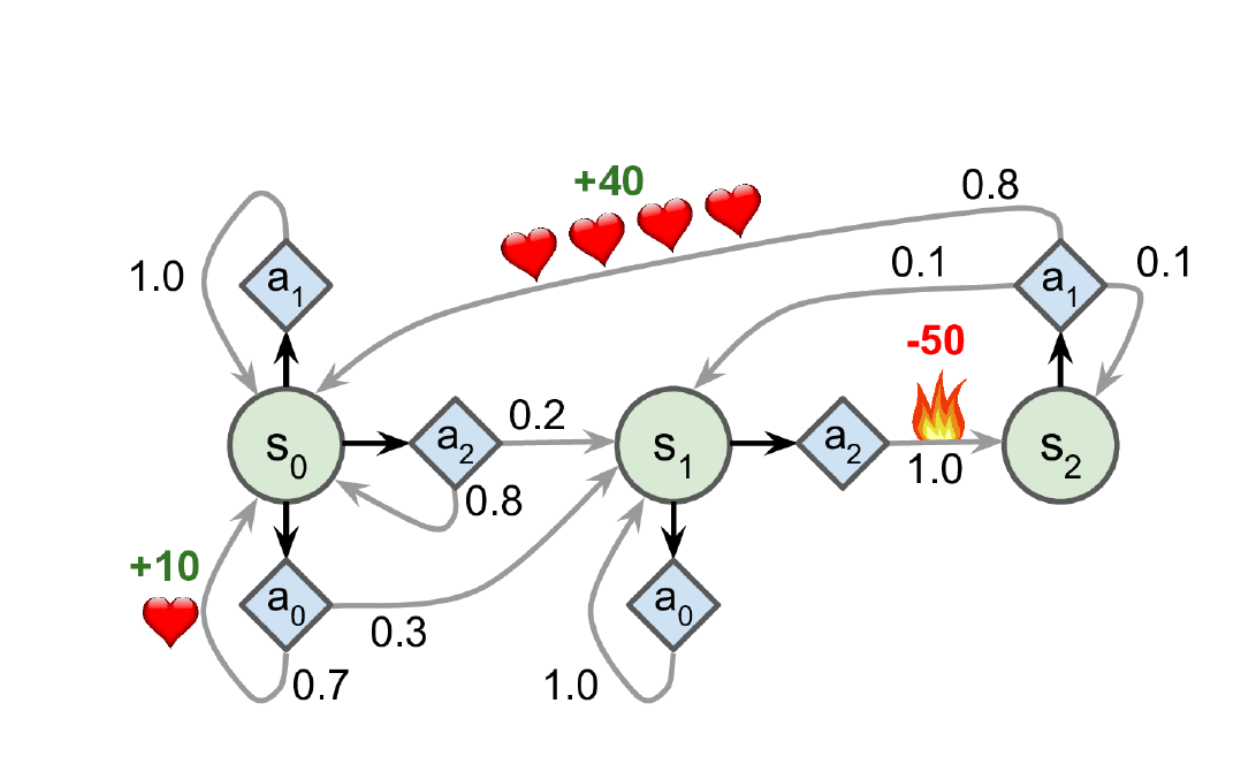

In [25]:
Q_values[2]

array([       -inf, 50.13365013,        -inf])

In [7]:
transition_probabilities = [ # shape=[s, a, s']
        [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
        [[0.0, 1.0, 0.0], None, [0.0, 0.0, 1.0]],
        [None, [0.8, 0.1, 0.1], None]
]
rewards = [ # shape=[s, a, s']
        [[+10, 0, 0], [0, 0, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
        [[0, 0, 0], [+40, 0, 0], [0, 0, 0]]]
possible_actions = [[0, 1, 2], [0, 2], [1]]

# Q-Value Iteration

Now we will initialize all the Q-Values to 0 (except for the the impossible actions, for which we set the Q-Values to –∞):

In [8]:
Q_values = np.full((3, 3), -np.inf) # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0  # for all possible actions

Now let's run the Q-Value Iteration algorithm:

In [19]:
gamma = 0.90  # the discount factor

history1 = [] # Not shown in the book (for the figure below)
for iteration in range(50):
    Q_prev = Q_values.copy()
    history1.append(Q_prev) # Not shown
    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                    transition_probabilities[s][a][sp]
                    * (rewards[s][a][sp] + gamma * np.max(Q_prev[sp]))
                for sp in range(3)])

history1 = np.array(history1) # Not shown

That’s it! The resulting Q-Values look like this:

18.918918918918912

For each state, let’s look at the action that has the highest Q-Value:

In [16]:
np.argmax(Q_values, axis=1)

array([0, 0, 1])

The optimal policy for this MDP, when using a discount factor of 0.90, is to choose action a0 when in state s0, and choose action a0 when in state s1, and finally choose action a1 (the only possible action) when in state s2.

Let's try again with a discount factor of 0.95:

In [ ]:
Q_values = np.full((3, 3), -np.inf) # -np.inf for impossible actions
for state, actions in enumerate(possible_actions):
    Q_values[state, actions] = 0.0  # for all possible actions

In [ ]:
gamma = 0.95  # the discount factor

for iteration in range(50):
    Q_prev = Q_values.copy()
    for s in range(3):
        for a in possible_actions[s]:
            Q_values[s, a] = np.sum([
                    transition_probabilities[s][a][sp]
                    * (rewards[s][a][sp] + gamma * np.max(Q_prev[sp]))
                for sp in range(3)])

In [ ]:
Q_values

In [ ]:
np.argmax(Q_values, axis=1)

Now the policy has changed! In state s1, we now prefer to go through the fire (choose action a2). This is because the discount factor is larger so the agent values the future more, and it is therefore ready to pay an immediate penalty in order to get more future rewards.

**Go Back to Slides**

# Q-Learning

Q-Learning works by watching an agent play (e.g., randomly) and gradually improving its estimates of the Q-Values. Once it has accurate Q-Value estimates (or close enough), then the optimal policy consists in choosing the action that has the highest Q-Value (i.e., the greedy policy).

We will need to simulate an agent moving around in the environment, so let's define a function to perform some action and get the new state and a reward:

In [26]:
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

We also need an exploration policy, which can be any policy, as long as it visits every possible state many times. We will just use a random policy, since the state space is very small:

In [ ]:
def exploration_policy(state):
    return np.random.choice(possible_actions[state])

Now let's initialize the Q-Values like earlier, and run the Q-Learning algorithm:

In [ ]:
np.random.seed(42)

Q_values = np.full((3, 3), -np.inf)
for state, actions in enumerate(possible_actions):
    Q_values[state][actions] = 0

alpha0 = 0.05 # initial learning rate
decay = 0.005 # learning rate decay
gamma = 0.90 # discount factor
state = 0 # initial state
history2 = [] # Not shown in the book

for iteration in range(10000):
    history2.append(Q_values.copy()) # Not shown
    action = exploration_policy(state)
    next_state, reward = step(state, action)
    next_value = np.max(Q_values[next_state]) # greedy policy at the next step
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_state

history2 = np.array(history2) # Not shown

In [ ]:
Q_values

In [ ]:
np.argmax(Q_values, axis=1) # optimal action for each state

In [ ]:
true_Q_value = history1[-1, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].set_ylabel("Q-Value$(s_0, a_0)$", fontsize=14)
axes[0].set_title("Q-Value Iteration", fontsize=14)
axes[1].set_title("Q-Learning", fontsize=14)
for ax, width, history in zip(axes, (50, 10000), (history1, history2)):
    ax.plot([0, width], [true_Q_value, true_Q_value], "k--")
    ax.plot(np.arange(width), history[:, 0, 0], "b-", linewidth=2)
    ax.set_xlabel("Iterations", fontsize=14)
    ax.axis([0, width, 0, 24])

The Q-Value Iteration algorithm (left) converges very quickly, in fewer than 20 iterations, while the Q-Learning algorithm (right) takes about 8,000 iterations to converge. Obviously, not knowing the transition probabilities or the rewards makes finding the optimal policy significantly harder!

**Go Back to the Slides**

# Deep Q-Network

Let's build the DQN. Given a state, it will estimate, for each possible action, the sum of discounted future rewards it can expect after it plays that action (but before it sees its outcome):

In [29]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

env = gym.make("CartPole-v1")
input_shape = [4] # == env.observation_space.shape
n_outputs = 2 # == env.action_space.n returns q-values of both the actions

model = keras.models.Sequential([
    keras.layers.Dense(4, activation="elu", input_shape=input_shape),
#     keras.layers.Dense(32, activation="elu"),
    keras.layers.Dense(n_outputs)
])

To select an action using this DQN, we just pick the action with the largest predicted Q-value. However, to ensure that the agent explores the environment, we choose a random action with probability `epsilon`.

In [35]:
def epsilon_greedy_policy(state, epsilon=.30):
    if np.random.rand() < epsilon:
        return np.random.randint(2)
    else:
        Q_values = model.predict(state[np.newaxis])
        return np.argmax(Q_values[0])

We will also need a replay memory. It will contain the agent's experiences, in the form of tuples: `(obs, action, reward, next_obs, done)`. We can use the `deque` class for that:

In [36]:
from collections import deque

replay_memory = deque(maxlen=2000)

And let's create a function to sample experiences from the replay memory. It will return 5 NumPy arrays: `[obs, actions, rewards, next_obs, dones]`.

In [38]:
def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_memory), size=batch_size)
    batch = [replay_memory[index] for index in indices]
    states, actions, rewards, next_states, dones = [
        np.array([experience[field_index] for experience in batch])
        for field_index in range(5)]
    return states, actions, rewards, next_states, dones

Now we can create a function that will use the DQN to play one step, and record its experience in the replay memory:

In [39]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, info = env.step(action)
    replay_memory.append((state, action, reward, next_state, done))
    return next_state, reward, done, info

Lastly, let's create a function that will sample some experiences from the replay memory and perform a training step:

**Note**: the first 3 releases of the 2nd edition were missing the `reshape()` operation which converts `target_Q_values` to a column vector (this is required by the `loss_fn()`).

In [42]:
tf.one_hot([1,1,2, 0, 1, 2], 3)

<tf.Tensor: shape=(6, 3), dtype=float32, numpy=
array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)>

In [43]:
batch_size = 32
discount_rate = 0.95
optimizer = keras.optimizers.Adam(lr=1e-3)
loss_fn = keras.losses.mean_squared_error

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones = experiences
    next_Q_values = model.predict(next_states)
    max_next_Q_values = np.max(next_Q_values, axis=1)
    target_Q_values = (rewards +
                       (1 - dones) * discount_rate * max_next_Q_values)
    target_Q_values = target_Q_values.reshape(-1, 1)
    
    # model.fit(states, target_Q_values)
    
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

/usr/local/anaconda/envs/tensorflow2/lib/python3.6/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


And now, let's train the model!

In [44]:
env.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

rewards = [] 
best_score = 0

**Please note:** We have set the number of episode range to 100, and step range to 50 in order to reduce the execution time during lectures. Please feel free to uncomment the original code and run it in the lab.

In [45]:
# for episode in range(600):
for episode in range(600):
    obs = env.reset()
    # for step in range(200):
    for step in range(500):
        epsilon = 0.9 #max(1 - episode / 500, 0.01)
#         epsilon = max(1 - episode / 10, 0.01)
        obs, reward, done, info = play_one_step(env, obs, epsilon)
        if done:
            break
    rewards.append(step) # Not shown in the book
    if step > best_score: # Not shown
        best_weights = model.get_weights() # Not shown
        best_score = step # Not shown
    print("\rEpisode: {}, Steps: {}, eps: {:.3f}".format(episode, step + 1, epsilon), end="") # Not shown
    if episode > 50:
        training_step(batch_size)

model.set_weights(best_weights)

Episode: 599, Steps: 14, eps: 0.900

![cart-pole](images/cart-pole-image3.png "Cart-Pole")

As you can see, the algorithm made no apparent progress at all for almost 300 episodes. Then its performance suddenly
skyrocketed up to 200. That’s great news: the algorithm worked fine, and it actually ran much faster than the Policy Gradient algorithm!

But just a few episodes later, it forgot everything it knew, and its performance dropped below 25! This is called catastrophic forgetting, and it is one of the big problems facing virtually all RL algorithms!

Also, we didn't plot the loss since it is a poor indicator of the model’s performance. The loss might go down, yet the agent might perform worse and vice-versa.

<video controls src="videos/cart-pole-video5.mp4" />

Not bad at all!

The basic Deep Q-Learning algorithm we’ve been using so far would be too unstable to learn to play Atari games. So how did DeepMind do it? Well, they tweaked the algorithm!

**Go Back to the Slides**

## Double DQN

In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential([
    keras.layers.Dense(32, activation="elu", input_shape=[4]),
    keras.layers.Dense(32, activation="elu"),
    keras.layers.Dense(n_outputs)
])

target = keras.models.clone_model(model)
target.set_weights(model.get_weights())

In [ ]:
batch_size = 32
discount_rate = 0.95
optimizer = keras.optimizers.Adam(lr=1e-3)
loss_fn = keras.losses.Huber()

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones = experiences
    next_Q_values = model.predict(next_states)
    best_next_actions = np.argmax(next_Q_values, axis=1)
    next_mask = tf.one_hot(best_next_actions, n_outputs).numpy()
    next_best_Q_values = (target.predict(next_states) * next_mask).sum(axis=1)
    target_Q_values = (rewards + 
                       (1 - dones) * discount_rate * next_best_Q_values)
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [ ]:
replay_memory = deque(maxlen=2000)

**Please note:** We have set the number of episode range to 100, and step range to 50 in order to reduce the execution time during lectures. Please feel free to uncomment the original code and run it in the lab.

In [ ]:
env.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

rewards = []
best_score = 0

# for episode in range(600):
for episode in range(100):
    obs = env.reset()
    # for step in range(200):
    for step in range(50):
        # epsilon = max(1 - episode / 500, 0.01)
        epsilon = max(1 - episode / 10, 0.01)
        obs, reward, done, info = play_one_step(env, obs, epsilon)
        if done:
            break
    rewards.append(step)
    if step > best_score:
        best_weights = model.get_weights()
        best_score = step
    print("\rEpisode: {}, Steps: {}, eps: {:.3f}".format(episode, step + 1, epsilon), end="")
    if episode > 50:
        training_step(batch_size)
    if episode % 50 == 0:
        target.set_weights(model.get_weights())
    # Alternatively, you can do soft updates at each step:
    #if episode > 50:
        #target_weights = target.get_weights()
        #online_weights = model.get_weights()
        #for index in range(len(target_weights)):
        #    target_weights[index] = 0.99 * target_weights[index] + 0.01 * online_weights[index]
        #target.set_weights(target_weights)

model.set_weights(best_weights)

![cart-pole](images/cart-pole-image4.png "Cart-Pole")

<video controls src="videos/cart-pole-video6.mp4" />

**Go Back to the Slides**

# Dueling Double DQN

In [ ]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

K = keras.backend
input_states = keras.layers.Input(shape=[4])
hidden1 = keras.layers.Dense(32, activation="elu")(input_states)
hidden2 = keras.layers.Dense(32, activation="elu")(hidden1)
state_values = keras.layers.Dense(1)(hidden2)
raw_advantages = keras.layers.Dense(n_outputs)(hidden2)
advantages = raw_advantages - K.max(raw_advantages, axis=1, keepdims=True)
Q_values = state_values + advantages
model = keras.models.Model(inputs=[input_states], outputs=[Q_values])

target = keras.models.clone_model(model)
target.set_weights(model.get_weights())

In [ ]:
batch_size = 32
discount_rate = 0.95
optimizer = keras.optimizers.Adam(lr=1e-2)
loss_fn = keras.losses.Huber()

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones = experiences
    next_Q_values = model.predict(next_states)
    best_next_actions = np.argmax(next_Q_values, axis=1)
    next_mask = tf.one_hot(best_next_actions, n_outputs).numpy()
    next_best_Q_values = (target.predict(next_states) * next_mask).sum(axis=1)
    target_Q_values = (rewards + 
                       (1 - dones) * discount_rate * next_best_Q_values)
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [ ]:
replay_memory = deque(maxlen=2000)

**Please note:** We have set the number of episode range to 100, and step range to 50 in order to reduce the execution time during lectures. Please feel free to uncomment the original code and run it in the lab.

In [ ]:
env.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

rewards = []
best_score = 0

# for episode in range(600):
for episode in range(100):
    obs = env.reset()
    # for step in range(200):
    for step in range(50):
        # epsilon = max(1 - episode / 500, 0.01)
        epsilon = max(1 - episode / 10, 0.01)
        obs, reward, done, info = play_one_step(env, obs, epsilon)
        if done:
            break
    rewards.append(step)
    if step > best_score:
        best_weights = model.get_weights()
        best_score = step
    print("\rEpisode: {}, Steps: {}, eps: {:.3f}".format(episode, step + 1, epsilon), end="")
    if episode > 50:
        training_step(batch_size)
    if episode % 200 == 0:
        target.set_weights(model.get_weights())

model.set_weights(best_weights)

![cart-pole](images/cart-pole-image5.png "Cart-Pole")

<video controls src="videos/cart-pole-video7.mp4" />

This looks like a pretty robust agent!

In [ ]:
env.close()

**Go Back to the Slides**

# Using TF-Agents to Beat Breakout

Let's use TF-Agents to create an agent that will learn to play Breakout. We will use the Deep Q-Learning algorithm, so you can easily compare the components with the previous implementation, but TF-Agents implements many other (and more sophisticated) algorithms!

## TF-Agents Environments

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
from tf_agents.environments import suite_gym

env = suite_gym.load("Breakout-v4")
env

In [ ]:
env.gym

In [ ]:
env.seed(42)
env.reset()

In [ ]:
env.step(1) # Fire

![cart-pole](images/breakout-plot-image1.png "Cart-Pole")

In [ ]:
env.current_time_step()

## Environment Specifications

In [ ]:
env.observation_spec()

In [ ]:
env.action_spec()

In [ ]:
env.time_step_spec()

## Environment Wrappers

You can wrap a TF-Agents environments in a TF-Agents wrapper:

In [ ]:
from tf_agents.environments.wrappers import ActionRepeat

repeating_env = ActionRepeat(env, times=4)
repeating_env

In [ ]:
repeating_env.unwrapped

Here is the list of available wrappers:

In [ ]:
import tf_agents.environments.wrappers

for name in dir(tf_agents.environments.wrappers):
    obj = getattr(tf_agents.environments.wrappers, name)
    if hasattr(obj, "__base__") and issubclass(obj, tf_agents.environments.wrappers.PyEnvironmentBaseWrapper):
        print("{:27s} {}".format(name, obj.__doc__.split("\n")[0]))

`ActionClipWrapper` = Clips the actions to the action spec.

`ActionDiscretizeWrapper` = Quantizes a continuous action space to a discrete action space.

`ActionRepeat` = Repeats each action over n steps, while accumulating the rewards. In many environments, this can speed up training significantly.

`RunStats` = Records environment statistics such as the number of steps and the number of episodes.

`TimeLimit` = Interrupts the environment if it runs for longer than a maximum number of steps.

`VideoWrapper` = Records a video of the environment.

The `suite_gym.load()` function can create an env and wrap it for you, both with TF-Agents environment wrappers and Gym environment wrappers (the latter are applied first).

In [ ]:
from functools import partial
from gym.wrappers import TimeLimit

limited_repeating_env = suite_gym.load(
    "Breakout-v4",
    gym_env_wrappers=[partial(TimeLimit, max_episode_steps=10000)],
    env_wrappers=[partial(ActionRepeat, times=4)],
)

Here is the list of preprocessing steps `AtariPreprocessing` wrapper supports:

Grayscale and downsampling = Observations are converted to grayscale and downsampled.

Max pooling = The last two frames of the game are max-pooled using a 1 × 1 filter to remove the flickering.

Frame skipping = The agent only gets to see every n frames of the game (by default n = 4), and its actions are repeated for each frame, collecting all the rewards.

End on life lost = In some games, the rewards are just based on the score, so the agent gets no immediate penalty for losing a life. One solution is to end the game immediately whenever a life is lost.

In [ ]:
limited_repeating_env

Create an Atari Breakout environment, and wrap it to apply the default Atari preprocessing steps:

In [ ]:
limited_repeating_env.unwrapped

In [ ]:
from tf_agents.environments import suite_atari
from tf_agents.environments.atari_preprocessing import AtariPreprocessing
from tf_agents.environments.atari_wrappers import FrameStack4

max_episode_steps = 27000 # <=> 108k ALE frames since 1 step = 4 frames
environment_name = "BreakoutNoFrameskip-v4"

env = suite_atari.load(
    environment_name,
    max_episode_steps=max_episode_steps,
    gym_env_wrappers=[AtariPreprocessing, FrameStack4])

In [ ]:
env

Play a few steps just to see what happens:

In [ ]:
env.seed(42)
env.reset()
time_step = env.step(1) # FIRE
for _ in range(4):
    time_step = env.step(3) # LEFT

In [ ]:
def plot_observation(obs):
    # Since there are only 3 color channels, you cannot display 4 frames
    # with one primary color per frame. So this code computes the delta between
    # the current frame and the mean of the other frames, and it adds this delta
    # to the red and blue channels to get a pink color for the current frame.
    obs = obs.astype(np.float32)
    img = obs[..., :3]
    current_frame_delta = np.maximum(obs[..., 3] - obs[..., :3].mean(axis=-1), 0.)
    img[..., 0] += current_frame_delta
    img[..., 2] += current_frame_delta
    img = np.clip(img / 150, 0, 1)
    plt.imshow(img)
    plt.axis("off")

![cart-pole](images/breakout-plot-image2.png "Cart-Pole")

From this single observation, the agent can see that the ball is going toward the lower-left corner, and that it should continue to move the paddle to the left.

Convert the Python environment to a TF environment:

In [ ]:
from tf_agents.environments.tf_py_environment import TFPyEnvironment

tf_env = TFPyEnvironment(env)

**Go Back to the Slides**

## Creating the DQN

Create a small class to normalize the observations. Images are stored using bytes from 0 to 255 to use less RAM, but we want to pass floats from 0.0 to 1.0 to the neural network:

Create the Q-Network:

This QNetwork takes an observation as input and outputs one Q-Value per action, so we must give it the specifications of the observations and the actions.

In [ ]:
from tf_agents.networks.q_network import QNetwork

# Casts the observations to 32-bit floats and normalizes them (the values will range from 0.0 to 1.0)
preprocessing_layer = keras.layers.Lambda(
                          lambda obs: tf.cast(obs, np.float32) / 255.)

# Encoding network will optionally apply a list of convolutions sequentially
# provided you specify their parameters via the next layer
conv_layer_params=[(32, (8, 8), 4), (64, (4, 4), 2), (64, (3, 3), 1)]

# After these convolutional layers, the encoding network will optionally apply
# a sequence of dense layers, if you set the next layer fc_layer_params argument
fc_layer_params=[512]

q_net = QNetwork(
    tf_env.observation_spec(),
    tf_env.action_spec(),
    preprocessing_layers=preprocessing_layer,
    conv_layer_params=conv_layer_params,
    fc_layer_params=fc_layer_params)

![cart-pole](images/encoding-network.png "Cart-Pole")

Create the DQN Agent:

In [ ]:
from tf_agents.agents.dqn.dqn_agent import DqnAgent

# see TF-agents issue #113
#optimizer = keras.optimizers.RMSprop(lr=2.5e-4, rho=0.95, momentum=0.0,
#                                     epsilon=0.00001, centered=True)

train_step = tf.Variable(0)
update_period = 4 # run a training step every 4 collect steps
optimizer = tf.compat.v1.train.RMSPropOptimizer(learning_rate=2.5e-4, decay=0.95, momentum=0.0,
                                     epsilon=0.00001, centered=True)

# Compute the ε value for the ε-greedy collect policy, given the current training step
epsilon_fn = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=1.0, # initial ε
    decay_steps=250000 // update_period, # <=> 1,000,000 ALE frames
    end_learning_rate=0.01) # final ε
agent = DqnAgent(tf_env.time_step_spec(),
                 tf_env.action_spec(),
                 q_network=q_net,
                 optimizer=optimizer,
                 target_update_period=2000, # <=> 32,000 ALE frames
                 td_errors_loss_fn=keras.losses.Huber(reduction="none"),
                 gamma=0.99, # discount factor
                 train_step_counter=train_step,
                 epsilon_greedy=lambda: epsilon_fn(train_step))
agent.initialize()

The TF-Agents library provides various replay buffer implementations in the `tf_agents.replay_buffers` package. We will use the `TFUniformReplayBuffer` class in the `tf_agents.replay_buffers.tf_uniform_replay_buffer` package. It provides a high-performance implementation of a replay buffer with uniform sampling:

**Plase note:** We have changed the buffer size to 1000 to suit our environment.

In [ ]:
from tf_agents.replay_buffers import tf_uniform_replay_buffer

replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    # Specification of the data that will be saved in the replay buffer
    data_spec=agent.collect_data_spec,
    # Number of trajectories that will be added at each step
    batch_size=tf_env.batch_size,
    # The maximum size of the replay buffer
    # max_length=1000000
    max_length=1000)

replay_buffer_observer = replay_buffer.add_batch

Create a simple custom observer that counts and displays the number of times it is called (except when it is passed a trajectory that represents the boundary between two episodes, as this does not count as a step):

In [ ]:
class ShowProgress:
    def __init__(self, total):
        self.counter = 0
        self.total = total
    def __call__(self, trajectory):
        if not trajectory.is_boundary():
            self.counter += 1
        if self.counter % 100 == 0:
            print("\r{}/{}".format(self.counter, self.total), end="")

TF-Agents implements several RL metrics in the `tf_agents.metrics` package, some purely in Python and some based on TensorFlow. Let's add some training metrics:

In [ ]:
from tf_agents.metrics import tf_metrics

train_metrics = [
    tf_metrics.NumberOfEpisodes(),
    tf_metrics.EnvironmentSteps(),
    tf_metrics.AverageReturnMetric(),
    tf_metrics.AverageEpisodeLengthMetric(),
]

In [ ]:
train_metrics[0].result()

In [ ]:
from tf_agents.eval.metric_utils import log_metrics
import logging
logging.getLogger().setLevel(logging.INFO)
log_metrics(train_metrics)

Create the collect driver:

In [ ]:
from tf_agents.drivers.dynamic_step_driver import DynamicStepDriver

collect_driver = DynamicStepDriver(
    tf_env,
    agent.collect_policy,
    observers=[replay_buffer_observer] + train_metrics,
    num_steps=update_period) # collect 4 steps for each training iteration

There are two main driver classes: `DynamicStepDriver` and `DynamicEpisodeDriver`. The first one collects experiences for a given number of steps, while the second collects experiences for a given number of episodes. We want to collect experiences for four steps for each training iteration (as was done in the 2015 DQN paper), so let’s create a `DynamicStepDriver` and collect the initial experiences, before training:

**Please note:** We have changed the number of steps.

In [ ]:
from tf_agents.policies.random_tf_policy import RandomTFPolicy

initial_collect_policy = RandomTFPolicy(tf_env.time_step_spec(),
                                        tf_env.action_spec())
init_driver = DynamicStepDriver(
    tf_env,
    initial_collect_policy,
    observers=[replay_buffer.add_batch, ShowProgress(20000)],
    num_steps=2000)
    # num_steps=20000) # <=> 80,000 ALE frames
final_time_step, final_policy_state = init_driver.run()

The following code will sample a small batch of two trajectories (subepisodes), each containing three consecutive steps. Let's sample 2 sub-episodes, with 3 time steps each and display them:

In [ ]:
tf.random.set_seed(888) # chosen to show an example of trajectory at the end of an episode

trajectories, buffer_info = replay_buffer.get_next(
    sample_batch_size=2, num_steps=3)

In [ ]:
trajectories._fields

In [ ]:
trajectories.observation.shape

In [ ]:
from tf_agents.trajectories.trajectory import to_transition

time_steps, action_steps, next_time_steps = to_transition(trajectories)
time_steps.observation.shape

In [ ]:
trajectories.step_type.numpy()

In [ ]:
plt.figure(figsize=(10, 6.8))
for row in range(2):
    for col in range(3):
        plt.subplot(2, 3, row * 3 + col + 1)
        plot_observation(trajectories.observation[row, col].numpy())
plt.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0, wspace=0.02)
plt.show()

Each trajectory is a concise representation of a sequence of consecutive time steps and action steps, designed to avoid redundancy.

![cart-pole](images/trajectories.png "Cart-Pole")

Now let's create the dataset:

In [ ]:
dataset = replay_buffer.as_dataset(
    sample_batch_size=64,
    num_steps=2,
    num_parallel_calls=3).prefetch(3)

Convert the main functions to TF Functions for better performance:

In [ ]:
from tf_agents.utils.common import function

collect_driver.run = function(collect_driver.run)
agent.train = function(agent.train)

And now we are ready to run the main loop!

In [ ]:
def train_agent(n_iterations):
    time_step = None
    policy_state = agent.collect_policy.get_initial_state(tf_env.batch_size)
    iterator = iter(dataset)
    for iteration in range(n_iterations):
        time_step, policy_state = collect_driver.run(time_step, policy_state)
        trajectories, buffer_info = next(iterator)
        train_loss = agent.train(trajectories)
        print("\r{} loss:{:.5f}".format(
            iteration, train_loss.loss.numpy()), end="")
        if iteration % 1000 == 0:
            log_metrics(train_metrics)

Run the next cell to train the agent for 10,000 steps. Then look at its behavior by running the following cell. You can run these two cells as many times as you wish. The agent will keep improving!

**Please note:** We have changed the number of iterations.

In [ ]:
# train_agent(n_iterations=10000)
train_agent(n_iterations=100)

In [ ]:
frames = []
def save_frames(trajectory):
    global frames
    frames.append(tf_env.pyenv.envs[0].render(mode="rgb_array"))

prev_lives = tf_env.pyenv.envs[0].ale.lives()
def reset_and_fire_on_life_lost(trajectory):
    global prev_lives
    lives = tf_env.pyenv.envs[0].ale.lives()
    if prev_lives != lives:
        tf_env.reset()
        tf_env.pyenv.envs[0].step(1)
        prev_lives = lives

watch_driver = DynamicStepDriver(
    tf_env,
    agent.policy,
    observers=[save_frames, reset_and_fire_on_life_lost, ShowProgress(1000)],
    num_steps=1000)
final_time_step, final_policy_state = watch_driver.run()

<video controls src="videos/breakout-plot-video1.mp4" />

**Go Back to the Slides**